News Article Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/New/Desktop/FODS_sarvvesh/news_text_analysis.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True, format="mixed", errors="coerce")
df = df.dropna(subset=['Timestamp'])
df = df.set_index('Timestamp')
df.index = df.index.tz_convert('UTC').tz_localize(None)

In [2]:
daily_posts = df.resample('D').size()
print("Number of posts per day:")
print(daily_posts.head())

Number of posts per day:
Timestamp
2025-06-09    1
2025-06-10    0
2025-06-11    0
2025-06-12    0
2025-06-13    1
Freq: D, dtype: int64


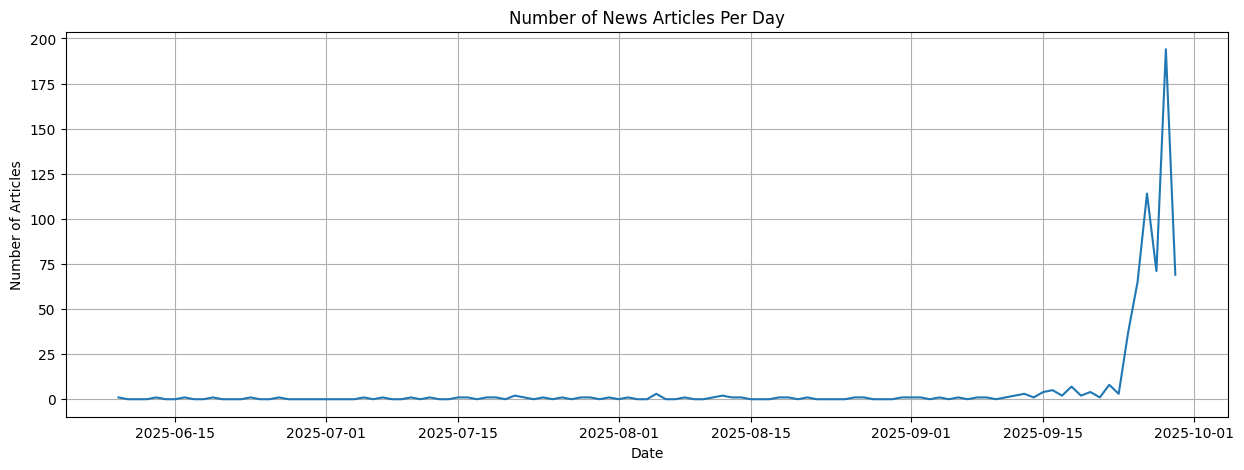

In [3]:
plt.figure(figsize=(15, 5))
plt.plot(daily_posts.index, daily_posts.values)
plt.title("Number of News Articles Per Day")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.grid(True)
plt.show()

C:\Users\New\AppData\Local\Temp\ipykernel_8692\179889170.py:2: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_source = df.groupby('Source').resample('D').size().unstack()


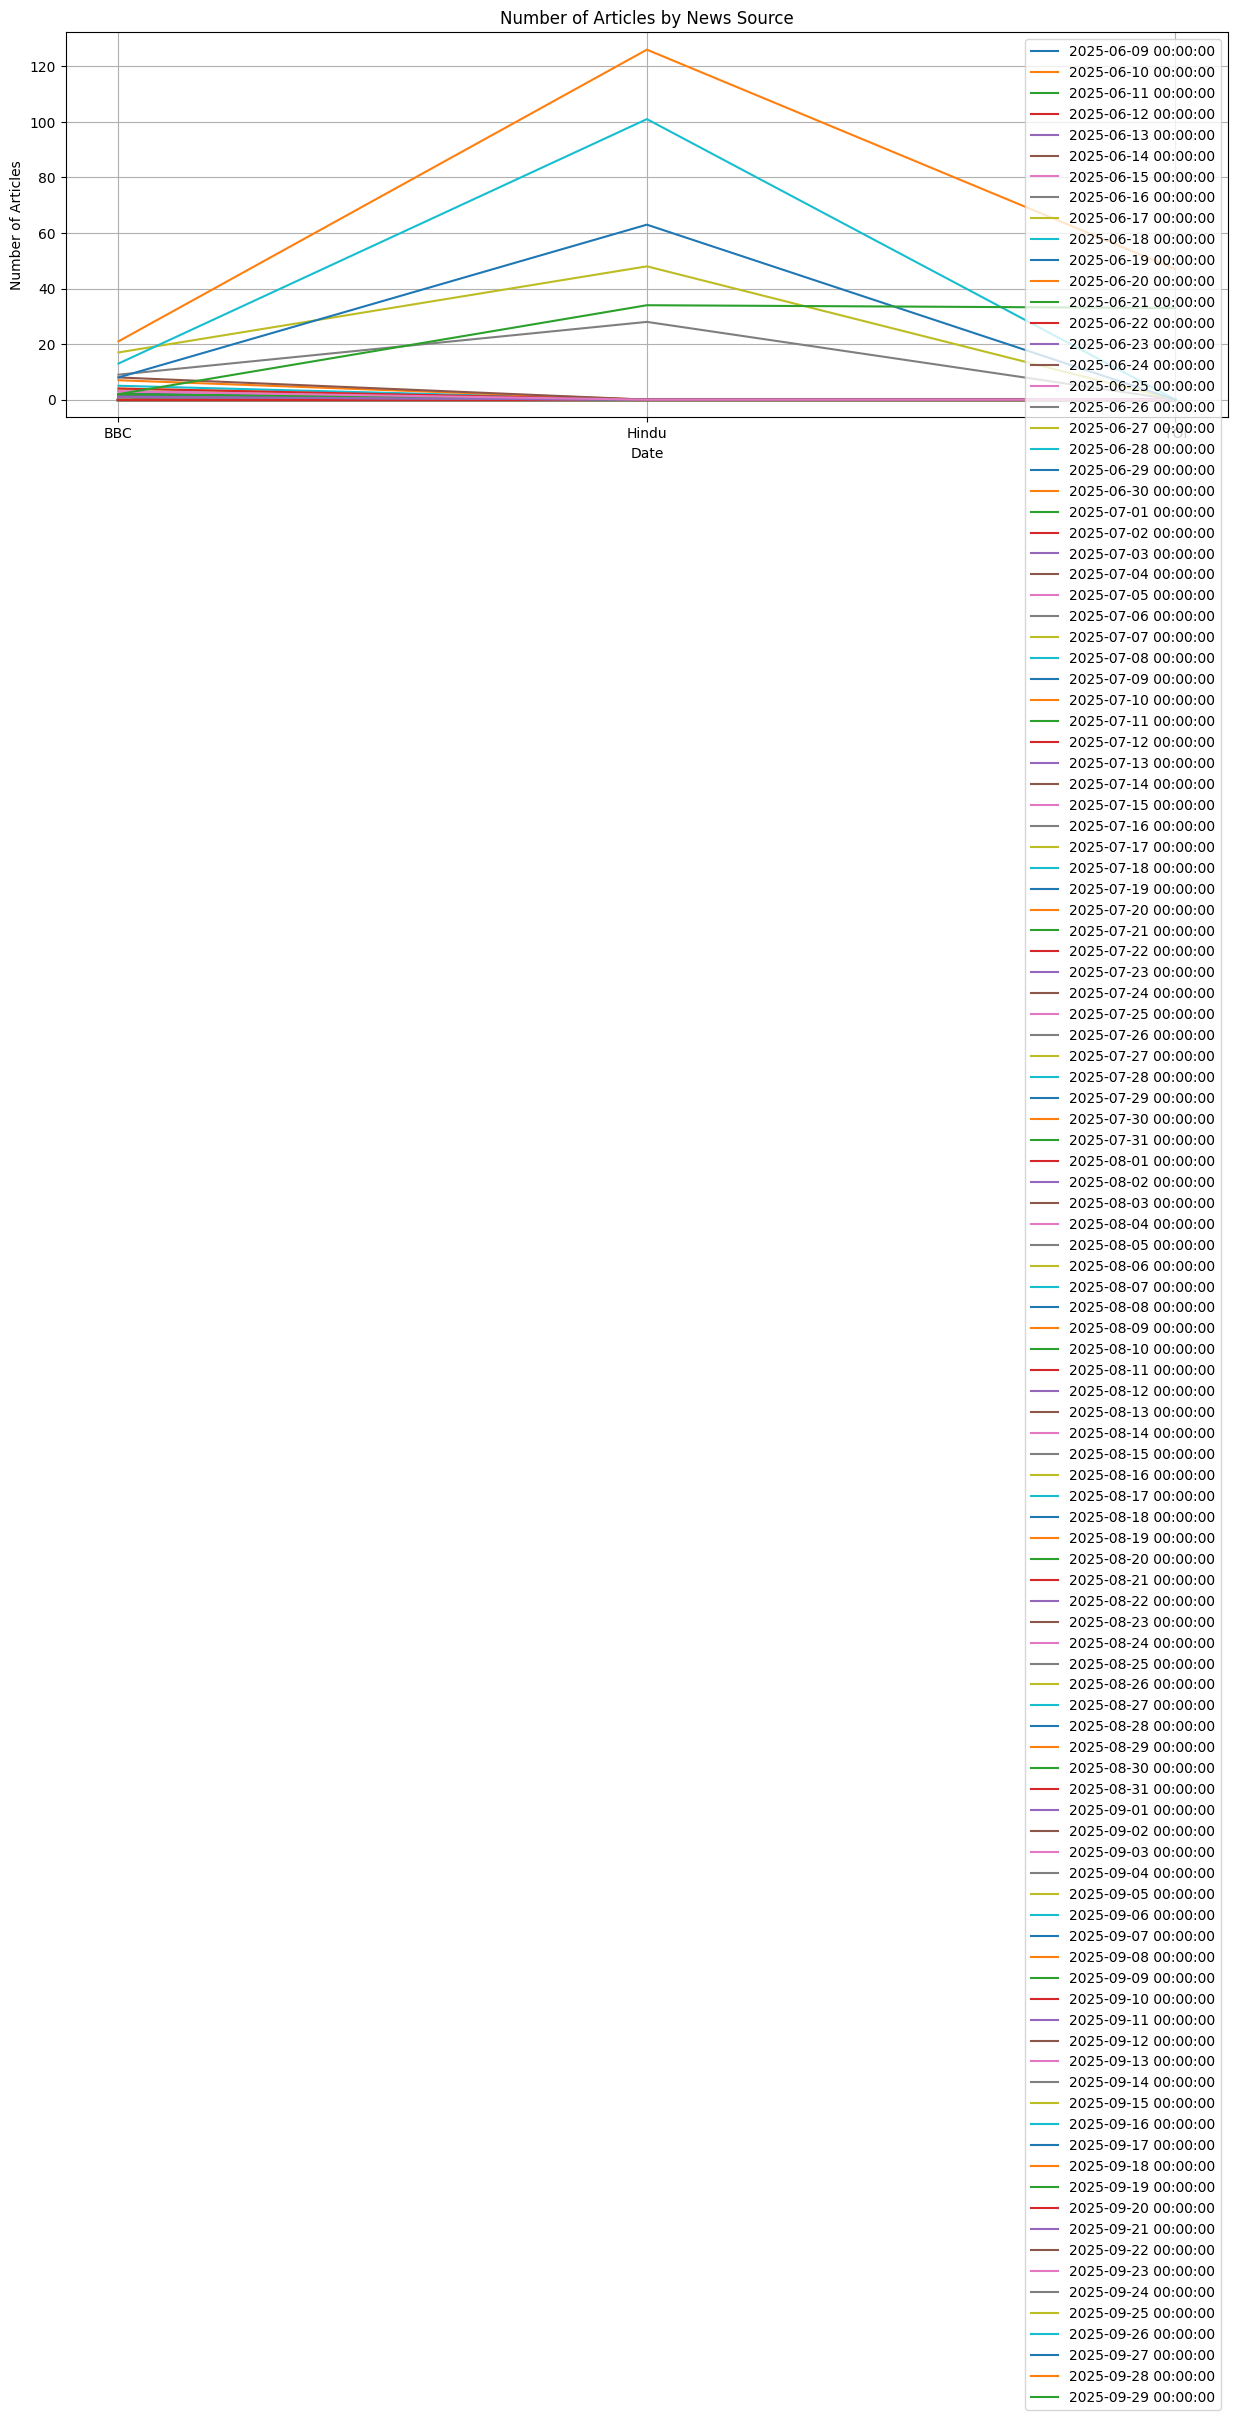

In [4]:
plt.figure(figsize=(15, 5))
by_source = df.groupby('Source').resample('D').size().unstack()
by_source = by_source.fillna(0)

for source in by_source.columns:
    plt.plot(by_source.index, by_source[source], label=source)

plt.title("Number of Articles by News Source")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.grid(True)
plt.legend()
plt.show()

C:\Users\New\AppData\Local\Temp\ipykernel_8692\1293939739.py:2: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_category = df.groupby('Category').resample('D').size().unstack()


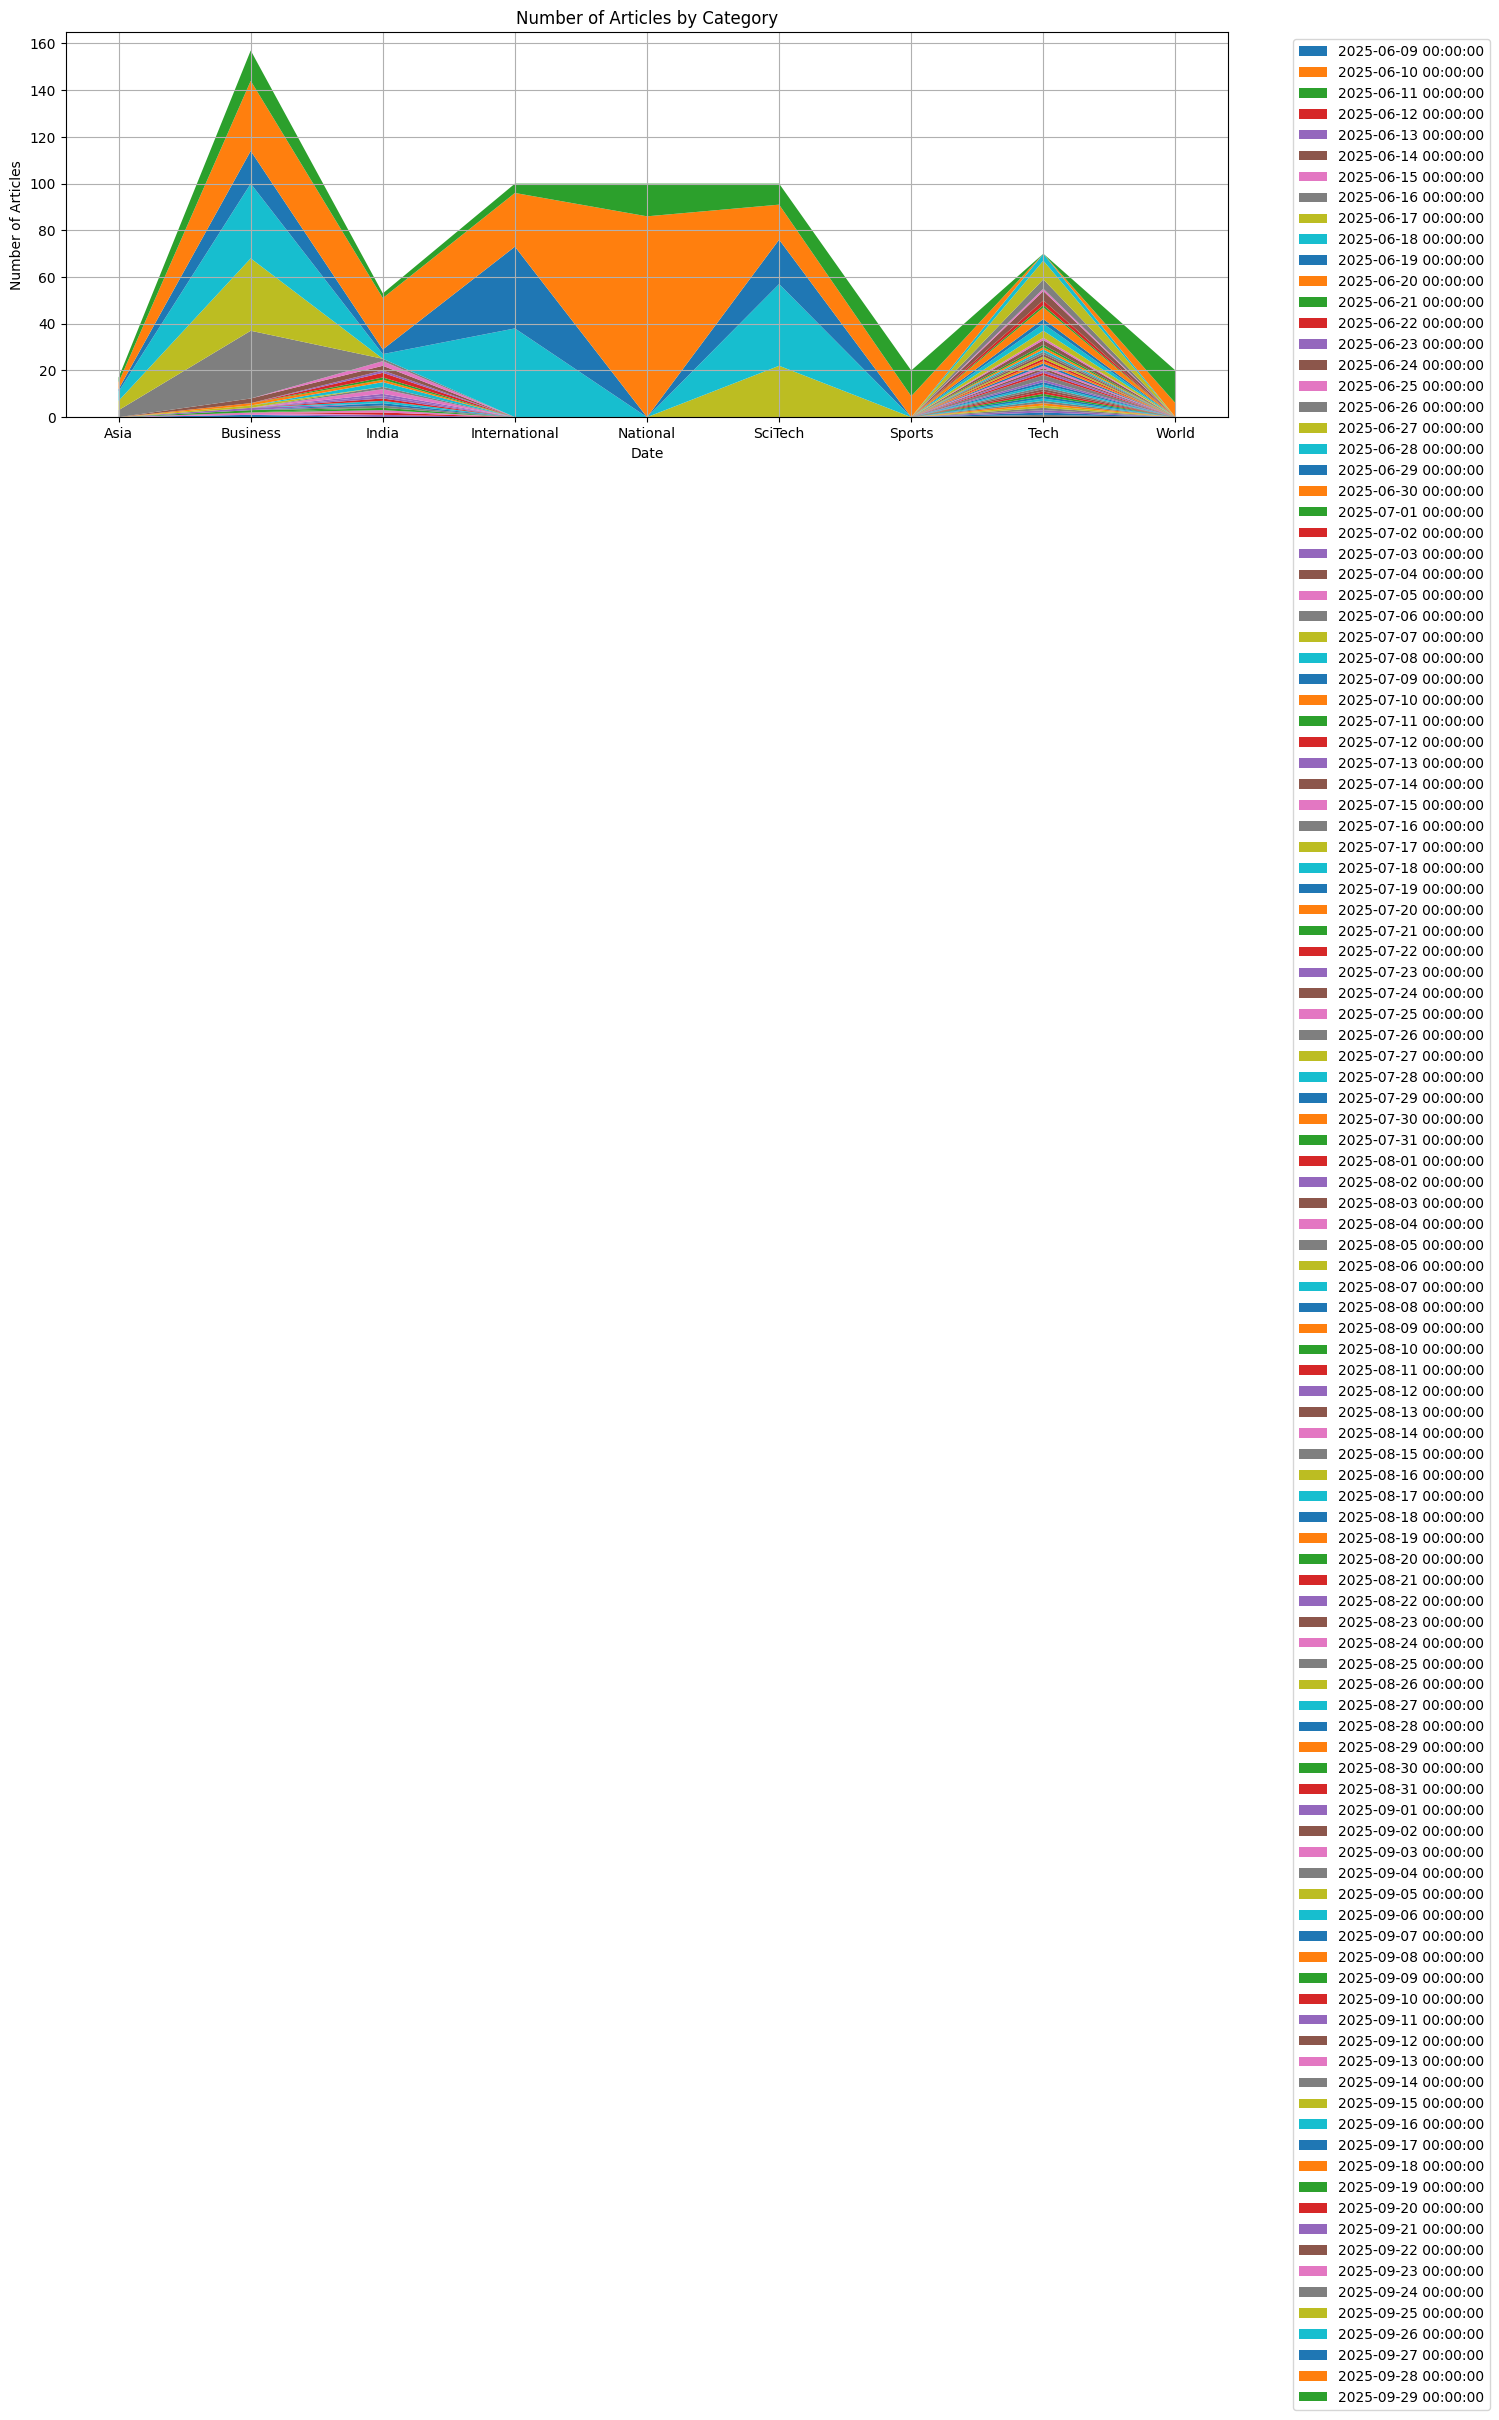

In [5]:
plt.figure(figsize=(15, 5))
by_category = df.groupby('Category').resample('D').size().unstack()
by_category = by_category.fillna(0)

plt.stackplot(by_category.index, [by_category[cat] for cat in by_category.columns], labels=by_category.columns)
plt.title("Number of Articles by Category")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [6]:
weekly_average = daily_posts.rolling(window=7).mean()
weekly_std = daily_posts.rolling(window=7).std()
z_scores = (daily_posts - weekly_average) / weekly_std
unusual_days = daily_posts[z_scores.abs() > 2]

print("Days with unusual number of articles:")
print(unusual_days)

Days with unusual number of articles:
Timestamp
2025-07-05     1
2025-08-05     3
2025-09-24    37
dtype: int64


In [7]:
print("\nHeadlines from unusual days:")
for date in unusual_days.index[:5]:
    print(f"\nDate: {date.date()}")
    daily_news = df.loc[date.strftime('%Y-%m-%d')]
    print(f"Number of articles: {len(daily_news)}")
    print("Sample headlines:")
    print(daily_news['Headline'].head(3))


Headlines from unusual days:

Date: 2025-07-05
Number of articles: 1
Sample headlines:
Timestamp
2025-07-05 16:11:02    Labour might be down, but it's not necessarily...
Name: Headline, dtype: object

Date: 2025-08-05
Number of articles: 3
Sample headlines:
Timestamp
2025-08-05 10:42:37    Terrifying video shows flash flood engulfing r...
2025-08-05 08:24:56                       The history behind the QR code
2025-08-05 19:30:00                                            Tech Life
Name: Headline, dtype: object

Date: 2025-09-24
Number of articles: 37
Sample headlines:
Timestamp
2025-09-24 17:24:40            No takers yet for govt’s EV import scheme
2025-09-24 17:17:25    Gem and Jewellery sector seeks urgent relief a...
2025-09-24 17:13:22    Justice on GST disputes will now be fair, fast...
Name: Headline, dtype: object
